In [8]:
from math import ceil

import matplotlib.pyplot as plt
import torch
import torch.utils.data

from fun.ct_dataset import CTPostProcessDataset
from fun.ellipses_dataset import EllipsesDataset

In [9]:
train_dataset = torch.utils.data.ConcatDataset(
    [
        #CTPostProcessDataset(EllipsesDataset(1, 1024, 10, binary_output=False, normalize_intensities=True), angle_threshold=128, angles=torch.linspace(0.0, torch.pi, 128), pos_count=32, target_shape=(64, 64), noise_type="gaussian", noise_level=0.2),
        #CTPostProcessDataset(EllipsesDataset(1, 1024, 10, binary_output=False, normalize_intensities=True), angle_threshold=256, angles=torch.linspace(0.0, torch.pi, 256), pos_count=64, target_shape=(128, 128), noise_type="gaussian", noise_level=0.2),
        CTPostProcessDataset(EllipsesDataset(1, 1024, 10, binary_output=False, normalize_intensities=True), angle_threshold=1024, angles=torch.linspace(0.0, torch.pi, 1024), pos_count=512, target_shape=(256, 256), noise_type="gaussian", noise_level=0.2),
    ]
)

dataset = EllipsesDataset(1, 1024, 10, binary_output=False, normalize_intensities=True)
percent = 0.75
train_dataset = torch.utils.data.ConcatDataset(
    [
        CTPostProcessDataset(dataset, angles=torch.linspace(0.0, torch.pi*percent, ceil(256*percent)), pos_count=128, target_shape=(64, 64), noise_type="gaussian", noise_level=0.2),
        CTPostProcessDataset(dataset, angles=torch.linspace(0.0, torch.pi*percent, ceil(512*percent)), pos_count=256, target_shape=(128, 128), noise_type="gaussian", noise_level=0.2),
        CTPostProcessDataset(dataset, angles=torch.linspace(0.0, torch.pi*percent, ceil(1024*percent)), pos_count=512, target_shape=(256, 256), noise_type="gaussian", noise_level=0.2),
        CTPostProcessDataset(dataset, angles=torch.linspace(0.0, torch.pi*percent, ceil(2048*percent)), pos_count=1024, target_shape=(1024, 1024), noise_type="gaussian", noise_level=0.2),
    ]
)

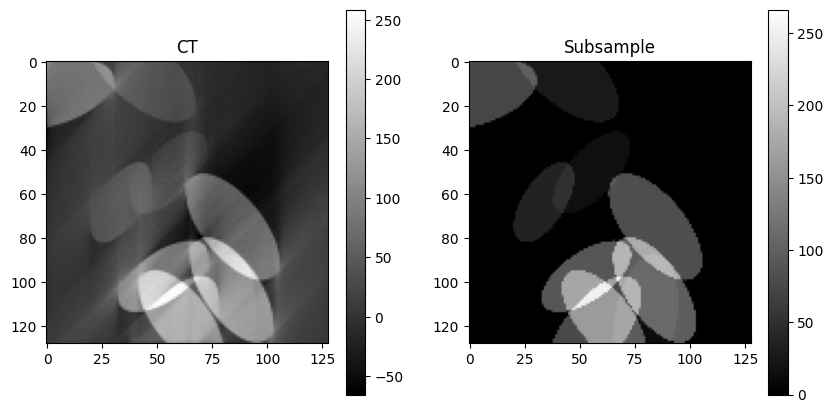

In [10]:
plt.subplots(1,2,figsize=(10,5))
plt.subplot(1,2,1)
plt.title("CT")
i = 1
plt.imshow(train_dataset[i]["input"][0].numpy(), cmap="gray")
plt.colorbar()
plt.subplot(1,2,2)
plt.title("Subsample")
plt.imshow(train_dataset[i]["target"][0].numpy(), cmap="gray")
plt.colorbar()
plt.show()